# 11 — Sensitivity: synthetic heterogeneity and minimum detectable δ

The five estimator families (T-learner, causal forest, BCF, interaction forest, in-context
model) find no exploitable effect heterogeneity on MASTER DAPT: all of them recover the
correct average ATE, but none clears the noise floor when the quality of the ranking is
evaluated (AUTOC lower bound via `DRTester`). "I didn't find it" is not the same as "it isn't
there" until we know the smallest heterogeneity the protocol would actually have been able to
see — this notebook produces that number (δ*), one per endpoint.

**Method, in brief** (full details in `PROMPT_delta_sensitivity.md`):

1. real covariates `X` unchanged;
2. baseline risk μ(x) — model local to this notebook (§4, motivated there);
3. direction of the synthetic heterogeneity g(x) — **open decision in the prompt, not
   specified at kickoff: we proceed with the default option (a real clinical covariate,
   §CONFIG) and flag it explicitly here and in the output**;
4. for each endpoint and each δ in the grid: sample `Y ~ Bernoulli(p(x))` with
   `p(x) = clip(μ(x) + T·δ·g(x), 0, 1)` (rare endpoints: odds-ratio scale, not risk-difference —
   §CONFIG), fit the tuned causal forest (same hyperparameters as the saved model), and
   evaluate with `score_cv_autoc`;
5. for the same δ, permute T (same scheme as `09_bcf_cate_estimation.ipynb`) and re-evaluate:
   this is the noise floor the observed signal is compared against, not zero;
6. δ* = the smallest δ for which the signal beats the floor in ≥90% of seeds.

**Constraints respected** (cf. `PROMPT_delta_sensitivity.md`): a single estimator (causal
forest); no existing file under `Meta-learning/models/` is written or overwritten (only
`joblib.load` in read-only mode); no Optuna journal is touched or rerun; no changes to
`casual_multioutput_pipeline.py` (only importing and calling `CausalMultiOutputPipeline`,
`.score_cv_autoc`); every new output goes to `Meta-learning/models/DeltaSensitivity/` (new
folder).


In [1]:
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from IPython.display import display
from joblib import Parallel, delayed

from casual_multioutput_pipeline import CausalMultiOutputPipeline, DEFAULT_NUISANCE_PARAMS

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

HERE = os.getcwd()
MODELS_DIR = os.path.normpath(os.path.join(HERE, "..", "models"))
DATA_DIR = os.path.normpath(os.path.join(HERE, "..", "..", "data"))
CF_DIR = os.path.join(MODELS_DIR, "CausalForest")
SAVE_DIR = os.path.join(MODELS_DIR, "DeltaSensitivity")   # new folder, sibling of BCF/ CausalForest/ ...
os.makedirs(SAVE_DIR, exist_ok=True)
print("models dir (read-only):", MODELS_DIR)
print("save dir (new, this notebook only):", SAVE_DIR)


models dir (read-only): /home/tpioda/Bachelor-Thesis/Meta-learning/models
save dir (new, this notebook only): /home/tpioda/Bachelor-Thesis/Meta-learning/models/DeltaSensitivity


/home/tpioda/Bachelor-Thesis/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 · Config — δ grids, seeds, g(x)

**g(x) — default decision applied** (§CONFIG below, `G_SOURCE_COLUMN`): patient age at
enrolment (`ic_age_mon`, months), standardized. Rationale: (1) it is the second most
important covariate causally in the already-saved tuned model for the `bleed` endpoint
(`pci_platel_pre` is first — verified with `pipe.get_feature_importances()` on the existing
model, read-only, before writing this notebook), so it is already a plausible modifier
according to the existing model, not an arbitrary choice; (2) it is a recognized component of
standard bleeding-risk scores (PRECISE-DAPT, ARC-HBR criteria); (3) it ties the result to the
narrative already present in the thesis about range restriction from HBR selection (the trial
enrolls only patients at high bleeding risk, of which age is a known determinant). Sign: g(x)
> 0 for older patients — clinically natural direction (higher age → higher bleeding risk →
more room for benefit from abbreviating / harm from prolonging). Easy to change:
`G_SOURCE_COLUMN` isolates the choice.

**δ on two scales** (§4 of the prompt): for `barc_235`/`bleed` (7.8%/11.1%, well powered) the
grid is an absolute risk difference, `[0, 0.01, 0.02, 0.05, 0.10]`, as suggested. For
`death`/`mi`/`stroke` (0.8%–2.4%) an additive δ of that magnitude would distort the
prevalence, so δ is a **log-odds-ratio** applied on the logit scale; the grid goes up to
OR = 1.5/2/3/5. The two scales still share the null point δ=0 (no effect), so the "reproduces
the noise floor at δ=0" comparison stays uniform across endpoints.


In [2]:
# ============================ CONFIG ============================
TARGET_LABELS = ["barc_235", "death", "mi", "stroke", "bleed"]

# Real event rates (data/y_targets.parquet), for reference/printing only.
EVENT_RATES = {"barc_235": 0.078, "death": 0.018, "mi": 0.024, "stroke": 0.008, "bleed": 0.111}

# g(x): see markdown above for the rationale behind the default choice.
G_SOURCE_COLUMN = "ic_age_mon"

# delta grids: 'risk_diff' -> delta is an absolute risk difference at g(x)=+1SD;
# 'log_or' -> delta is a shift in log-odds-ratio at g(x)=+1SD (rare endpoints). 0.0 = null
# on both scales.
_LOG_OR_GRID = [0.0, float(np.log(1.5)), float(np.log(2.0)), float(np.log(3.0)), float(np.log(5.0))]
DELTA_GRIDS = {
    "barc_235": {"scale": "risk_diff", "values": [0.0, 0.01, 0.02, 0.05, 0.10]},
    "bleed":    {"scale": "risk_diff", "values": [0.0, 0.01, 0.02, 0.05, 0.10]},
    "death":    {"scale": "log_or",    "values": _LOG_OR_GRID},
    "mi":       {"scale": "log_or",    "values": _LOG_OR_GRID},
    "stroke":   {"scale": "log_or",    "values": _LOG_OR_GRID},
}

N_SEEDS = 20                  # noise seeds per (endpoint, delta) -- 20-50 suggested by the prompt
N_CV = 3                      # score_cv_autoc folds (default of the existing tuning)
Z = 1.0                       # lower-bound multiplier (default of the existing tuning)
DETECTION_THRESHOLD = 0.90    # delta* = smallest delta with observed > floor in >=90% of seeds
RANDOM_SEED_BASE = 1000

INNER_N_JOBS = 8              # threads/processes inside a single CausalForestDML fit
OUTER_N_JOBS = 64            # (endpoint,delta,seed) tasks in parallel

MULTIOUT = os.path.join(CF_DIR, "CausalForest_multioutput_tuned.joblib")

print("endpoints:", TARGET_LABELS)
print("g(x) source column:", G_SOURCE_COLUMN)
for lab in TARGET_LABELS:
    g = DELTA_GRIDS[lab]
    print(f"  {lab:9s} rate={EVENT_RATES[lab]:.3f}  scale={g['scale']:9s} "
          f"grid={[round(v, 3) for v in g['values']]}")
print(f"N_SEEDS={N_SEEDS}  N_CV={N_CV}  detection_threshold={DETECTION_THRESHOLD}")
print(f"parallelism: OUTER_N_JOBS={OUTER_N_JOBS} x INNER_N_JOBS={INNER_N_JOBS} (cpu_count={os.cpu_count()})")
n_tasks = sum(len(DELTA_GRIDS[lab]["values"]) for lab in TARGET_LABELS) * N_SEEDS
print(f"total tasks (endpoint, delta, seed): {n_tasks} (each ~2 fit+score of the causal forest)")


endpoints: ['barc_235', 'death', 'mi', 'stroke', 'bleed']
g(x) source column: ic_age_mon
  barc_235  rate=0.078  scale=risk_diff grid=[0.0, 0.01, 0.02, 0.05, 0.1]
  death     rate=0.018  scale=log_or    grid=[0.0, 0.405, 0.693, 1.099, 1.609]
  mi        rate=0.024  scale=log_or    grid=[0.0, 0.405, 0.693, 1.099, 1.609]
  stroke    rate=0.008  scale=log_or    grid=[0.0, 0.405, 0.693, 1.099, 1.609]
  bleed     rate=0.111  scale=risk_diff grid=[0.0, 0.01, 0.02, 0.05, 0.1]
N_SEEDS=20  N_CV=3  detection_threshold=0.9
parallelism: OUTER_N_JOBS=64 x INNER_N_JOBS=8 (cpu_count=192)
total tasks (endpoint, delta, seed): 500 (each ~2 fit+score of the causal forest)


## 2 · Data (read-only) — same X/Y/T as the tuned model

`tuning_data.npz` contains exactly the `X`/`Y`/`T` the tuned model was fitted on (same row and
column order as `X_features.parquet`, verified below), the same file already used read-only by
`10_bleeding_ischemic_tradeoff.ipynb`. No writes.


In [3]:
d = np.load(os.path.join(HERE, "tuning_data.npz"), allow_pickle=True)
X = d["X"]                      # (n, 63) raw numeric features, column order of the fitted model
Y = pd.DataFrame(d["Y"], columns=TARGET_LABELS).apply(pd.to_numeric, errors="coerce").to_numpy(dtype=int)
T = d["T"].astype(int)
n = X.shape[0]

Xfeat = pd.read_parquet(os.path.join(DATA_DIR, "X_features.parquet"))
num_cols = list(Xfeat.select_dtypes(include=[np.number]).columns)
assert len(num_cols) == X.shape[1], "numeric columns of X_features.parquet != tuning_data.npz X"
age_idx = num_cols.index(G_SOURCE_COLUMN)
# row-by-row alignment check between tuning_data.npz and X_features.parquet
assert np.allclose(X[:, age_idx].astype(float), Xfeat[G_SOURCE_COLUMN].to_numpy(dtype=float)), \
    "row order not aligned between tuning_data.npz and X_features.parquet"

age = X[:, age_idx].astype(float)
G = (age - age.mean()) / age.std()   # g(x): standardized age (z-score)

print(f"n = {n} patients | {X.shape[1]} numeric features | "
      f"{int((T == 1).sum())} prolonged (T=1), {int((T == 0).sum())} abbreviated (T=0)")
print(f"g(x) = z-score({G_SOURCE_COLUMN}); mean age = {age.mean() / 12:.1f}y, sd = {age.std() / 12:.1f}y")
for j, lab in enumerate(TARGET_LABELS):
    print(f"  {lab:9s} real events = {int(Y[:, j].sum())} ({Y[:, j].mean():.4f})")


n = 4579 patients | 63 numeric features | 2284 prolonged (T=1), 2295 abbreviated (T=0)
g(x) = z-score(ic_age_mon); mean age = 76.0y, sd = 8.7y
  barc_235  real events = 359 (0.0784)
  death     real events = 81 (0.0177)
  mi        real events = 109 (0.0238)
  stroke    real events = 35 (0.0076)
  bleed     real events = 506 (0.1105)


## 3 · Model hyperparameters — read from the tuned pipeline (read-only)

`joblib.load` on the already-saved model, only to read its `cf_params`/`nuisance_params`: no
`joblib.dump` ever touches it. `inference` is forced to `False` — the BLB bootstrap is needed
for per-patient confidence intervals (`predict_cate_std`), not for the point ranking used by
`score_cv_autoc`; disabling it only saves computation, every other hyperparameter stays
identical to the saved model.


In [4]:
pipe_tuned = joblib.load(MULTIOUT)   # read-only: never re-saved, never re-fitted here
CF_PARAMS = dict(pipe_tuned.cf_params, inference=False)
NUISANCE_PARAMS = dict(pipe_tuned.nuisance_params)
del pipe_tuned

print("causal forest hyperparameters (from the tuned model, read-only):")
for k, v in CF_PARAMS.items():
    print(f"  {k}: {v}")
print("nuisance hyperparameters (first-stage LGBM):")
for k, v in NUISANCE_PARAMS.items():
    print(f"  {k}: {v}")


causal forest hyperparameters (from the tuned model, read-only):
  n_estimators: 728
  subforest_size: 8
  max_depth: 15
  min_samples_leaf: 80
  max_samples: 0.4115373986566774
  max_features: 1.0
  inference: False
nuisance hyperparameters (first-stage LGBM):
  n_estimators: 100
  max_depth: 4
  num_leaves: 15
  min_child_samples: 20
  learning_rate: 0.05


## 4 · Baseline risk μ(x) — model local to this notebook

The already-saved multi-output models (`Meta-learning/models/base_models/*_gf_multioutput_*.joblib`,
meant to cover all five endpoints) expect **60 features**, while `X_features.parquet` today
has **63**: they don't apply cleanly to the current data. Per the prompt's fallback clause, a
minimal μ(x) is refit here — **local to this notebook, never saved outside `SAVE_DIR`, never
overwriting an existing model**: one LGBM classifier per endpoint, the same regularized
configuration already used as the causal forest's nuisance model (`DEFAULT_NUISANCE_PARAMS`),
fitted only on the T=0 arm (abbreviated) — this is the baseline risk on top of which the
synthetic effect `T·δ·g(x)` is later added.


In [5]:
from lightgbm import LGBMClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler


def fit_mu(y_binary, control_mask):
    """mu(x) = E[Y | X=x, T=0], model local to this notebook (see markdown above)."""
    Xc = pd.DataFrame(X).apply(pd.to_numeric, errors="coerce")
    X_imp = SimpleImputer(strategy="median").fit_transform(Xc)
    X_scaled = RobustScaler().fit_transform(X_imp)
    clf = LGBMClassifier(**dict(DEFAULT_NUISANCE_PARAMS, random_state=42, verbose=-1, n_jobs=4))
    clf.fit(X_scaled[control_mask], y_binary[control_mask])
    return clf.predict_proba(X_scaled)[:, 1]


MU = {}
rows = []
for j, lab in enumerate(TARGET_LABELS):
    y = Y[:, j]
    mu = fit_mu(y, control_mask=(T == 0))
    MU[lab] = mu
    rows.append({"endpoint": lab, "real_prevalence": y.mean(),
                 "mean_mu_all": mu.mean(), "mean_mu_T0(fit sample)": mu[T == 0].mean(),
                 "mean_mu_T1": mu[T == 1].mean()})
mu_calib = pd.DataFrame(rows).set_index("endpoint")
print(mu_calib.round(4).to_string())


          real_prevalence  mean_mu_all  mean_mu_T0(fit sample)  mean_mu_T1
endpoint                                                                  
barc_235           0.0784       0.0417                  0.0645      0.0188
death              0.0177       0.0083                  0.0161      0.0004
mi                 0.0238       0.0138                  0.0261      0.0014
stroke             0.0076       0.0026                  0.0052      0.0000
bleed              0.1105       0.0637                  0.0881      0.0392


## 5 · Synthetic outcome and evaluation — core functions

`synthetic_probability` implements point 4 of the prompt (Bernoulli on clipped probability,
two scales). `run_task` runs one full cycle for a single `(endpoint, delta, seed)`: samples
synthetic `Y`, fits+evaluates the tuned causal forest with real `T` (observed signal), then
repeats with permuted `T` (noise floor, point 7 of the prompt) — same synthetic `Y` in both
cases, only the treatment assignment changes.


In [6]:
def synthetic_probability(mu, T, delta, g, scale):
    """p(x) = clip(mu(x) + T*delta*g(x), 0, 1) on the risk-diff scale, or the analogous
    logit-scale (odds-ratio) version for rare endpoints (see CONFIG markdown)."""
    from scipy.special import expit, logit   # local import: avoids a loky pickling issue with
                                              # scipy.special ufuncs referenced from the
                                              # notebook's globals in the worker processes
    if scale == "risk_diff":
        p = mu + T * delta * g
    elif scale == "log_or":
        mu_c = np.clip(mu, 1e-4, 1 - 1e-4)
        p = expit(logit(mu_c) + T * delta * g)
    else:
        raise ValueError(scale)
    return np.clip(p, 0.0, 1.0)


def _fit_score(Y_col, T_vec, n_jobs_inner):
    """One fit+score_cv_autoc on a fresh pipeline; returns the AUTOC lower bound
    (score_cv_autoc returns its negation, meant for Optuna's minimize convention)."""
    pipe = CausalMultiOutputPipeline(cf_params=CF_PARAMS, nuisance_params=NUISANCE_PARAMS,
                                      n_jobs=n_jobs_inner, lgbm_n_jobs=2)
    return -pipe.score_cv_autoc(X, Y_col, T_vec, cv=N_CV, z=Z)


def run_task(endpoint, delta, seed):
    scale = DELTA_GRIDS[endpoint]["scale"]
    rng = np.random.default_rng(RANDOM_SEED_BASE + seed)
    p = synthetic_probability(MU[endpoint], T, delta, G, scale)
    Y_synth = rng.binomial(1, p).reshape(-1, 1)

    observed = _fit_score(Y_synth, T, INNER_N_JOBS)
    T_perm = rng.permutation(T)
    floor = _fit_score(Y_synth, T_perm, INNER_N_JOBS)

    return dict(endpoint=endpoint, delta=delta, seed=seed,
                observed_autoc=observed, floor_autoc=floor,
                synth_prevalence=float(Y_synth.mean()))


print("scoring functions ready")


scoring functions ready


## 6 · Execution — full grid

⚠️ Compute-heavy: ~$2 \times$ `n_tasks` fit+score runs of a causal forest with thousands of
trees. Parallelized over `OUTER_N_JOBS` outer processes (each with `INNER_N_JOBS` inner
threads), estimated time printed below before starting.


In [7]:
tasks = [(lab, delta, seed)
         for lab in TARGET_LABELS
         for delta in DELTA_GRIDS[lab]["values"]
         for seed in range(N_SEEDS)]
print(f"{len(tasks)} tasks queued, parallelism {OUTER_N_JOBS}x "
      f"(~{2 * len(tasks) * 30 / OUTER_N_JOBS / 60:.0f} min estimated at ~30s/fit+score)")

t0 = time.time()
records = Parallel(n_jobs=OUTER_N_JOBS, verbose=10)(
    delayed(run_task)(lab, delta, seed) for lab, delta, seed in tasks
)
print(f"completed in {(time.time() - t0) / 60:.1f} min")

results_df = pd.DataFrame(records)
results_df.to_csv(os.path.join(SAVE_DIR, "delta_sensitivity_raw.csv"), index=False)
display(results_df.head())


500 tasks queued, parallelism 64x (~8 min estimated at ~30s/fit+score)


[Parallel(n_jobs=64)]: Using backend LokyBackend with 64 concurrent workers.
[Parallel(n_jobs=64)]: Done  17 tasks      | elapsed:   29.3s
[Parallel(n_jobs=64)]: Done  34 tasks      | elapsed:   30.3s
[Parallel(n_jobs=64)]: Done  53 tasks      | elapsed:   32.3s
[Parallel(n_jobs=64)]: Done  72 tasks      | elapsed:   54.3s
[Parallel(n_jobs=64)]: Done  93 tasks      | elapsed:   56.7s
[Parallel(n_jobs=64)]: Done 114 tasks      | elapsed:  1.0min
[Parallel(n_jobs=64)]: Done 137 tasks      | elapsed:  1.3min
[Parallel(n_jobs=64)]: Done 160 tasks      | elapsed:  1.4min
[Parallel(n_jobs=64)]: Done 185 tasks      | elapsed:  1.5min
[Parallel(n_jobs=64)]: Done 210 tasks      | elapsed:  1.8min
[Parallel(n_jobs=64)]: Done 237 tasks      | elapsed:  1.9min
[Parallel(n_jobs=64)]: Done 264 tasks      | elapsed:  2.2min
[Parallel(n_jobs=64)]: Done 293 tasks      | elapsed:  2.4min
[Parallel(n_jobs=64)]: Done 322 tasks      | elapsed:  2.6min
[Parallel(n_jobs=64)]: Done 353 tasks      | elapsed:  

completed in 3.7 min


[Parallel(n_jobs=64)]: Done 500 out of 500 | elapsed:  3.7min finished


,endpoint,delta,seed,observed_autoc,floor_autoc,synth_prevalence
0,barc_235,0.0000,0,-0.0047,-0.0121,0.0400
1,barc_235,0.0000,1,-0.0024,-0.0132,0.0373
2,barc_235,0.0000,2,-0.0024,-0.0057,0.0400
3,barc_235,0.0000,3,-0.0032,0.0016,0.0417
4,barc_235,0.0000,4,-0.0037,-0.0127,0.0415


## 7 · Noise floor and δ* per endpoint

For each `(endpoint, delta)`, a paired comparison (same seed) between observed signal and
floor: `detect_frac` = fraction of seeds in which the observed value beats the floor. δ* is
the smallest δ in the grid with `detect_frac >= DETECTION_THRESHOLD`; if no δ reaches it, δ*
stays `NaN` ("not identified on this grid").


In [8]:
rows = []
for lab in TARGET_LABELS:
    sub_lab = results_df[results_df.endpoint == lab]
    for delta in DELTA_GRIDS[lab]["values"]:
        sub = sub_lab[sub_lab.delta == delta]
        detect_frac = float((sub.observed_autoc > sub.floor_autoc).mean())
        rows.append({"endpoint": lab, "delta": delta, "scale": DELTA_GRIDS[lab]["scale"],
                     "detect_frac": detect_frac,
                     "mean_observed": sub.observed_autoc.mean(),
                     "mean_floor": sub.floor_autoc.mean(),
                     "n_seeds": len(sub)})
detect_df = pd.DataFrame(rows)
detect_df.to_csv(os.path.join(SAVE_DIR, "detect_frac_by_delta.csv"), index=False)

delta_star = {}
for lab in TARGET_LABELS:
    d_lab = detect_df[detect_df.endpoint == lab].sort_values("delta")
    hit = d_lab[d_lab.detect_frac >= DETECTION_THRESHOLD]
    delta_star[lab] = float(hit.delta.iloc[0]) if len(hit) else float("nan")

ate_real = {}
summary_rows = []
for j, lab in enumerate(TARGET_LABELS):
    ate_real[lab] = float(Y[T == 1, j].mean() - Y[T == 0, j].mean())
    ds = delta_star[lab]
    scale = DELTA_GRIDS[lab]["scale"]
    if np.isnan(ds):
        display_val = f"> {DELTA_GRIDS[lab]['values'][-1]:.3g} (not reached on the grid)"
    elif scale == "risk_diff":
        display_val = f"{ds:.3f} (absolute risk difference)"
    else:
        display_val = f"OR = {np.exp(ds):.2f}"
    summary_rows.append({"endpoint": lab, "event_rate": EVENT_RATES[lab],
                         "real_ATE": ate_real[lab], "delta_star_raw": ds,
                         "delta_star_display": display_val})
delta_star_summary = pd.DataFrame(summary_rows).set_index("endpoint")
delta_star_summary.to_csv(os.path.join(SAVE_DIR, "delta_star_summary.csv"))
display(delta_star_summary)


,event_rate,real_ATE,delta_star_raw,delta_star_display
endpoint,,,,
barc_235,0.0780,0.0279,0.1000,0.100 (absolute risk difference)
death,0.0180,0.0031,0.0000,OR = 1.00
mi,0.0240,-0.0047,0.0000,OR = 1.00
stroke,0.0080,0.0048,NaN,> 1.61 (not reached on the grid)
bleed,0.1110,0.0451,0.1000,0.100 (absolute risk difference)


## 8 · Per-endpoint curves

X axis: δ as risk difference (`barc_235`, `bleed`) or equivalent odds ratio `exp(δ)` (`death`,
`mi`, `stroke`). Band = 10th-90th percentile across seeds.


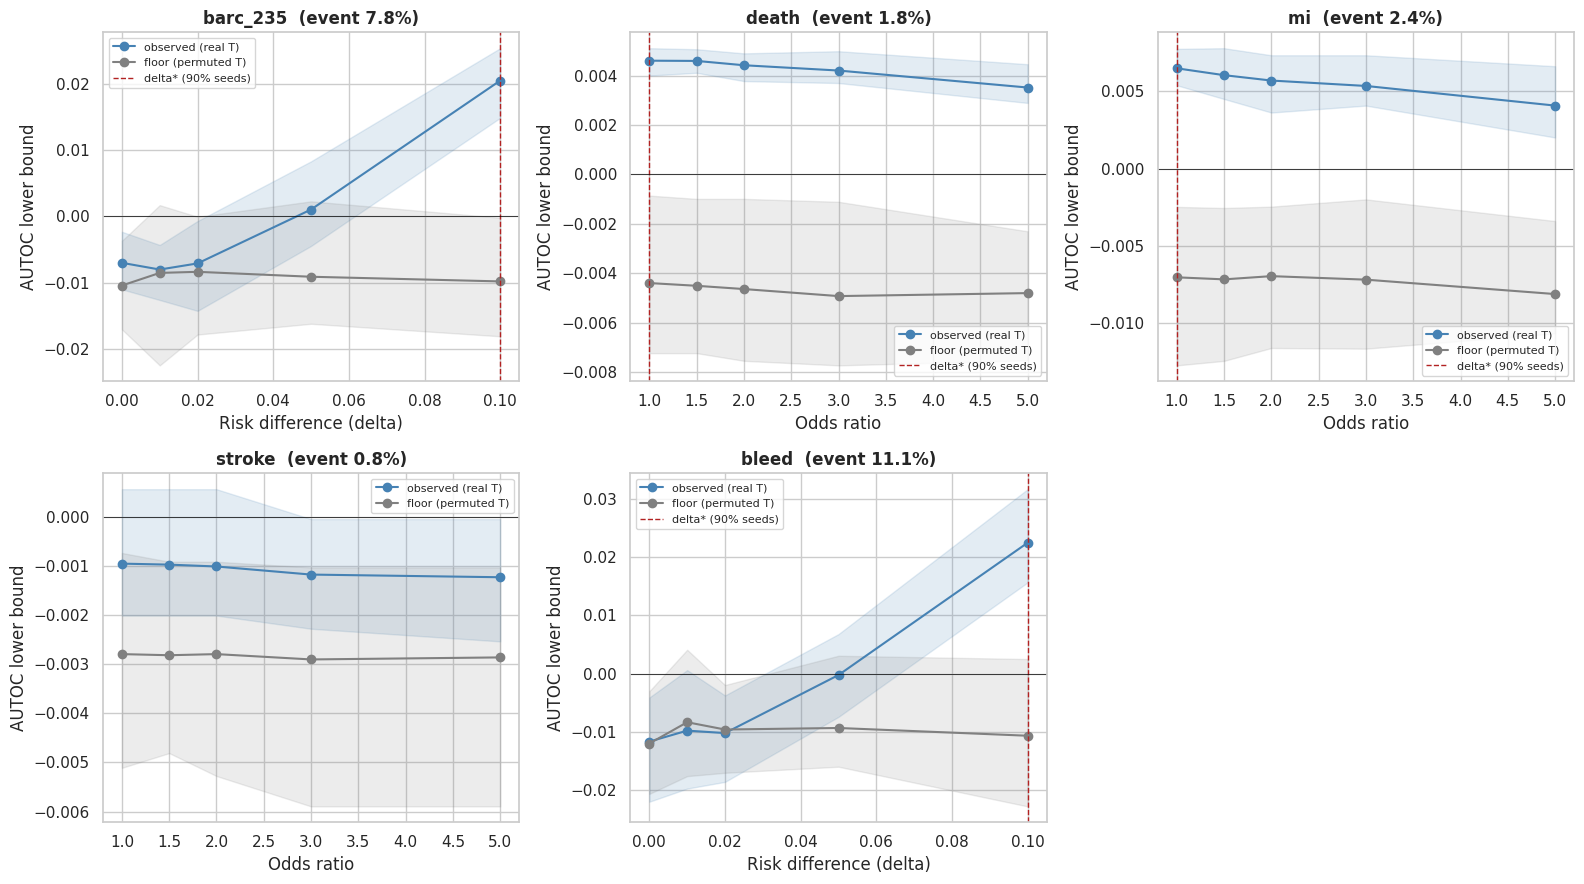

saved: /home/tpioda/Bachelor-Thesis/Meta-learning/models/DeltaSensitivity/delta_sensitivity_all.png


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()
for ax, lab in zip(axes, TARGET_LABELS):
    scale = DELTA_GRIDS[lab]["scale"]
    sub = results_df[results_df.endpoint == lab]
    deltas = DELTA_GRIDS[lab]["values"]
    x_display = [np.exp(dd) if scale == "log_or" else dd for dd in deltas]

    for col, color, label in [("observed_autoc", "steelblue", "observed (real T)"),
                               ("floor_autoc", "grey", "floor (permuted T)")]:
        means = [sub[sub.delta == dd][col].mean() for dd in deltas]
        lo = [sub[sub.delta == dd][col].quantile(0.10) for dd in deltas]
        hi = [sub[sub.delta == dd][col].quantile(0.90) for dd in deltas]
        ax.plot(x_display, means, "-o", color=color, label=label)
        ax.fill_between(x_display, lo, hi, color=color, alpha=0.15)

    ds = delta_star[lab]
    if not np.isnan(ds):
        ds_display = np.exp(ds) if scale == "log_or" else ds
        ax.axvline(ds_display, color="firebrick", linestyle="--", linewidth=1,
                  label=f"delta* ({DETECTION_THRESHOLD:.0%} seeds)")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title(f"{lab}  (event {EVENT_RATES[lab]:.1%})", fontweight="bold")
    ax.set_xlabel("Odds ratio" if scale == "log_or" else "Risk difference (delta)")
    ax.set_ylabel("AUTOC lower bound")
    ax.legend(fontsize=8)

axes[-1].axis("off")
plt.tight_layout()
fig_path = os.path.join(SAVE_DIR, "delta_sensitivity_all.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("saved:", fig_path)


## 9 · Paragraph for the outline

Text generated from the numbers above, to be reported (after review) in the fourth paragraph ⚠️
of `markdown_docs/thesis/scaletta_tesi_v3.md`, section "Il punto d'arrivo".


In [10]:
lines = []
for lab in TARGET_LABELS:
    ds = delta_star[lab]
    scale = DELTA_GRIDS[lab]["scale"]
    if np.isnan(ds):
        lines.append(f"- **{lab}**: no delta in the grid (up to "
                     f"{DELTA_GRIDS[lab]['values'][-1]:.3g}, scale {scale}) beat the "
                     f"noise floor in {DETECTION_THRESHOLD:.0%} of seeds -> delta* not "
                     f"identified on this grid, it needs to be extended.")
    elif scale == "risk_diff":
        lines.append(f"- **{lab}** (event {EVENT_RATES[lab]:.1%}): delta* = {ds:.3f} "
                     f"absolute risk difference (real observed ATE = {ate_real[lab]:+.4f}).")
    else:
        lines.append(f"- **{lab}** (event {EVENT_RATES[lab]:.1%}): delta* = OR {np.exp(ds):.2f} "
                     f"(real observed ATE = {ate_real[lab]:+.4f}).")
print("Paragraph for the outline (section 'Il punto d'arrivo'):\n")
print("\n".join(lines))


Paragraph for the outline (section 'Il punto d'arrivo'):

- **barc_235** (event 7.8%): delta* = 0.100 absolute risk difference (real observed ATE = +0.0279).
- **death** (event 1.8%): delta* = OR 1.00 (real observed ATE = +0.0031).
- **mi** (event 2.4%): delta* = OR 1.00 (real observed ATE = -0.0047).
- **stroke**: no delta in the grid (up to 1.61, scale log_or) beat the noise floor in 90% of seeds -> delta* not identified on this grid, it needs to be extended.
- **bleed** (event 11.1%): delta* = 0.100 absolute risk difference (real observed ATE = +0.0451).
